### 🟠Imports

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from scipy.stats import kruskal

import missingno as msno 

### 🟢Clinical Demographic Data EDA

Load the dataset & Set plotting style

In [ ]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

Clinical_Demographic = pd.read_csv('D:\\TCGA-BRCA\\Uploading\\Clinical_Demographic_Data.csv')

In [4]:
print("### 1. Basic Dataset Overview ###")
print(f"Shape: {Clinical_Demographic.shape}")
print("\nMissing Values Per Column (Top 10):")
print(Clinical_Demographic.isnull().sum().sort_values(ascending=False).head(10))

### 1. Basic Dataset Overview ###
Shape: (122, 84)

Missing Values Per Column (Top 10):
follow_ups_days_to_recurrence                          120
demographic_days_to_death                              119
follow_ups_days_to_progression                         118
diagnoses_tumor_of_origin                              117
follow_ups_progression_or_recurrence                   117
follow_ups_progression_or_recurrence_anatomic_site     117
follow_ups_progression_or_recurrence_type              117
follow_ups_molecular_tests_copy_number                 112
follow_ups_molecular_tests_cell_count                  111
follow_ups_molecular_tests_staining_intensity_scale    103
dtype: int64


Gender & Age & Vital status

C:\Users\USER\AppData\Local\Temp\ipykernel_20848\163170587.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Clinical_Demographic, x='demographic_gender', ax=axes[0], palette='viridis')
C:\Users\USER\AppData\Local\Temp\ipykernel_20848\163170587.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Clinical_Demographic, x='demographic_vital_status', ax=axes[2], palette='magma')


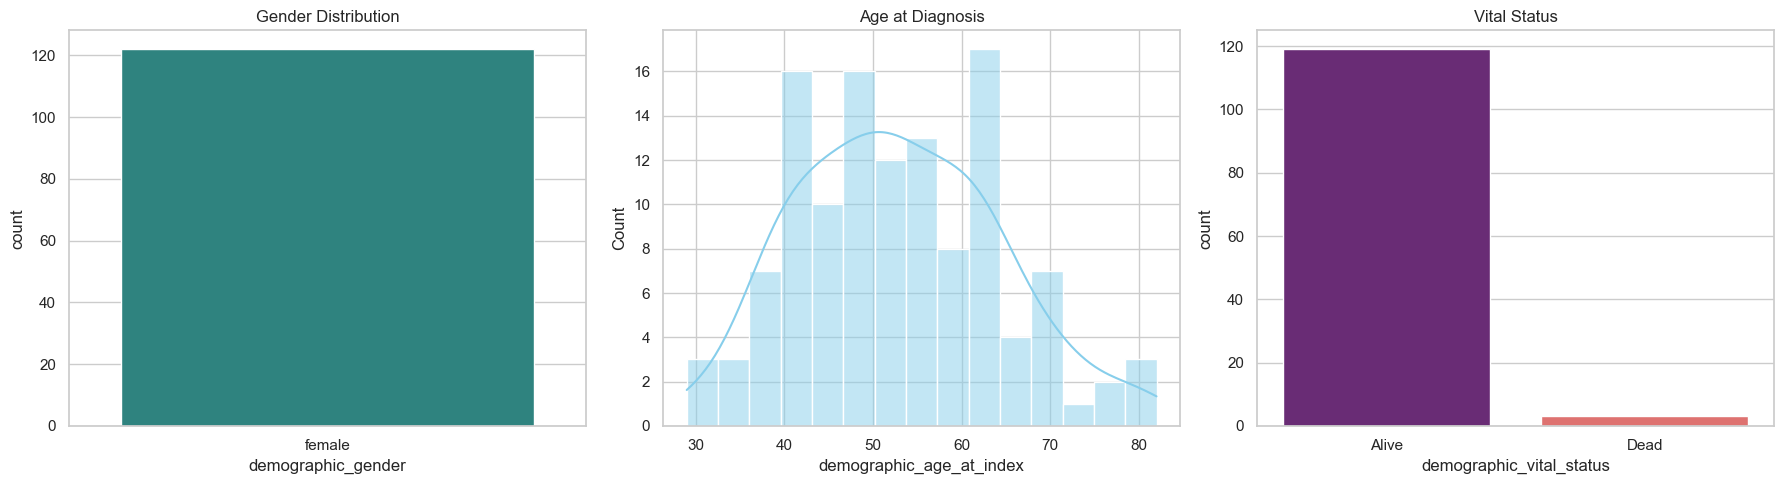

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=Clinical_Demographic, x='demographic_gender', ax=axes[0], palette='viridis')
axes[0].set_title('Gender Distribution')

sns.histplot(Clinical_Demographic['demographic_age_at_index'], bins=15, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Age at Diagnosis')

sns.countplot(data=Clinical_Demographic, x='demographic_vital_status', ax=axes[2], palette='magma')
axes[2].set_title('Vital Status')
plt.tight_layout()
plt.show()

Distribution of Pathologic Stages

C:\Users\USER\AppData\Local\Temp\ipykernel_20848\3648682960.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Clinical_Demographic, y='diagnoses_ajcc_pathologic_stage', order=order, palette='Set2')


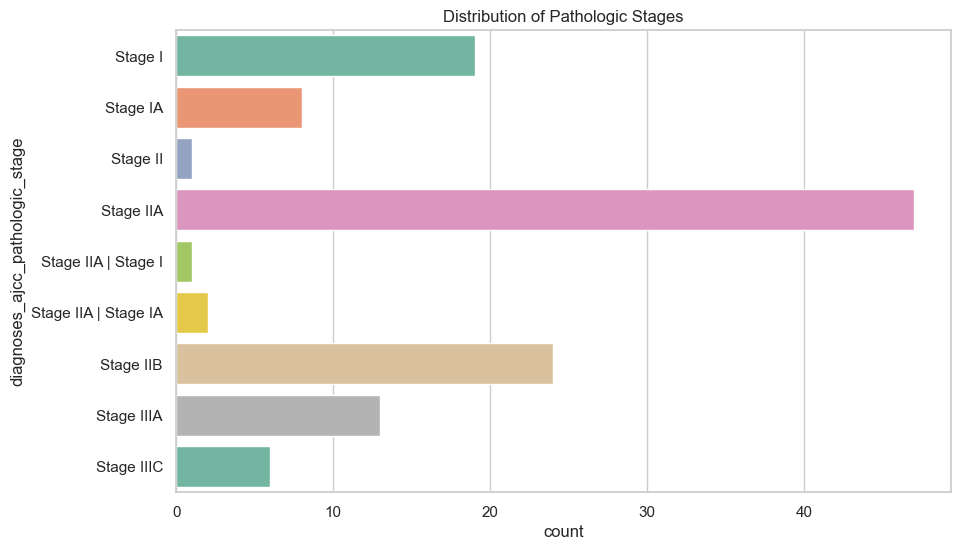

In [ ]:
plt.figure(figsize=(10, 6))
order = sorted(Clinical_Demographic['diagnoses_ajcc_pathologic_stage'].dropna().unique())
sns.countplot(data=Clinical_Demographic, y='diagnoses_ajcc_pathologic_stage', order=order, palette='Set2')
plt.title('Distribution of Pathologic Stages')
plt.show()

Molecular Markers Analysis (Handling Piped Values)

C:\Users\USER\AppData\Local\Temp\ipykernel_20848\3758726887.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Clinical_Demographic, x='primary_gene', palette='rocket')


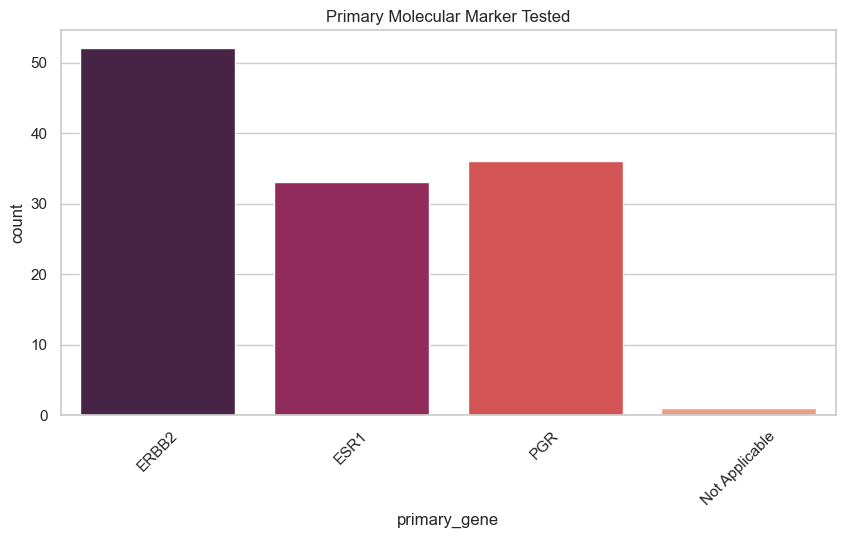

In [ ]:
# Many values are "ERBB2 | PGR | ESR1". Let's see the primary gene listed.
Clinical_Demographic['primary_gene'] = Clinical_Demographic['follow_ups_molecular_tests_gene_symbol'].str.split('|').str[0].str.strip()

plt.figure(figsize=(10, 5))
sns.countplot(data=Clinical_Demographic, x='primary_gene', palette='rocket')
plt.title('Primary Molecular Marker Tested')
plt.xticks(rotation=45)
plt.show()

Treatment Analysi

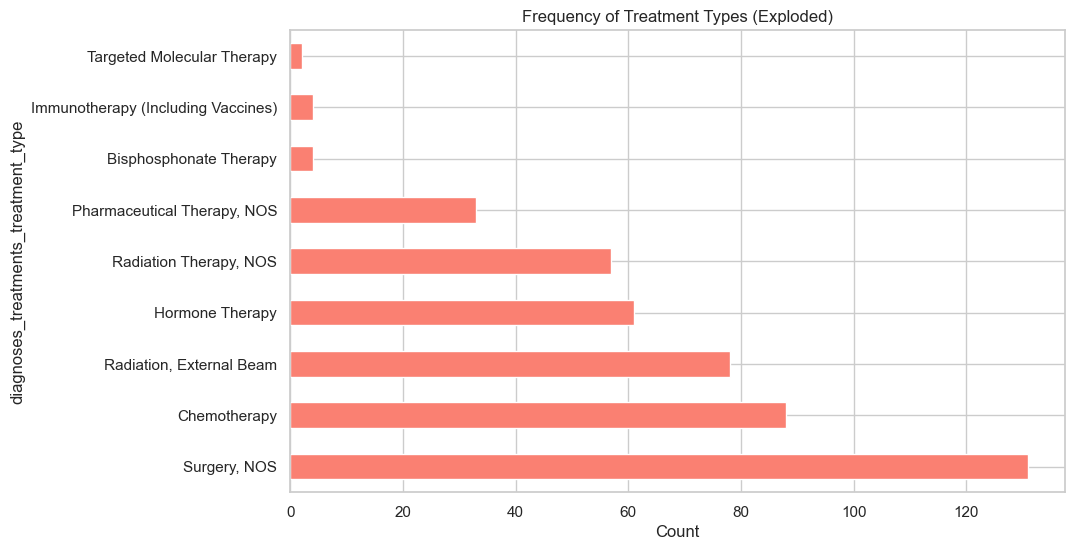

In [ ]:
# Splitting the piped treatment types to see what's most common
all_treatments = Clinical_Demographic['diagnoses_treatments_treatment_type'].str.split('|').explode().str.strip()

plt.figure(figsize=(10, 6))
all_treatments.value_counts().plot(kind='barh', color='salmon')
plt.title('Frequency of Treatment Types (Exploded)')
plt.xlabel('Count')
plt.show()

Correlation Heatmap 

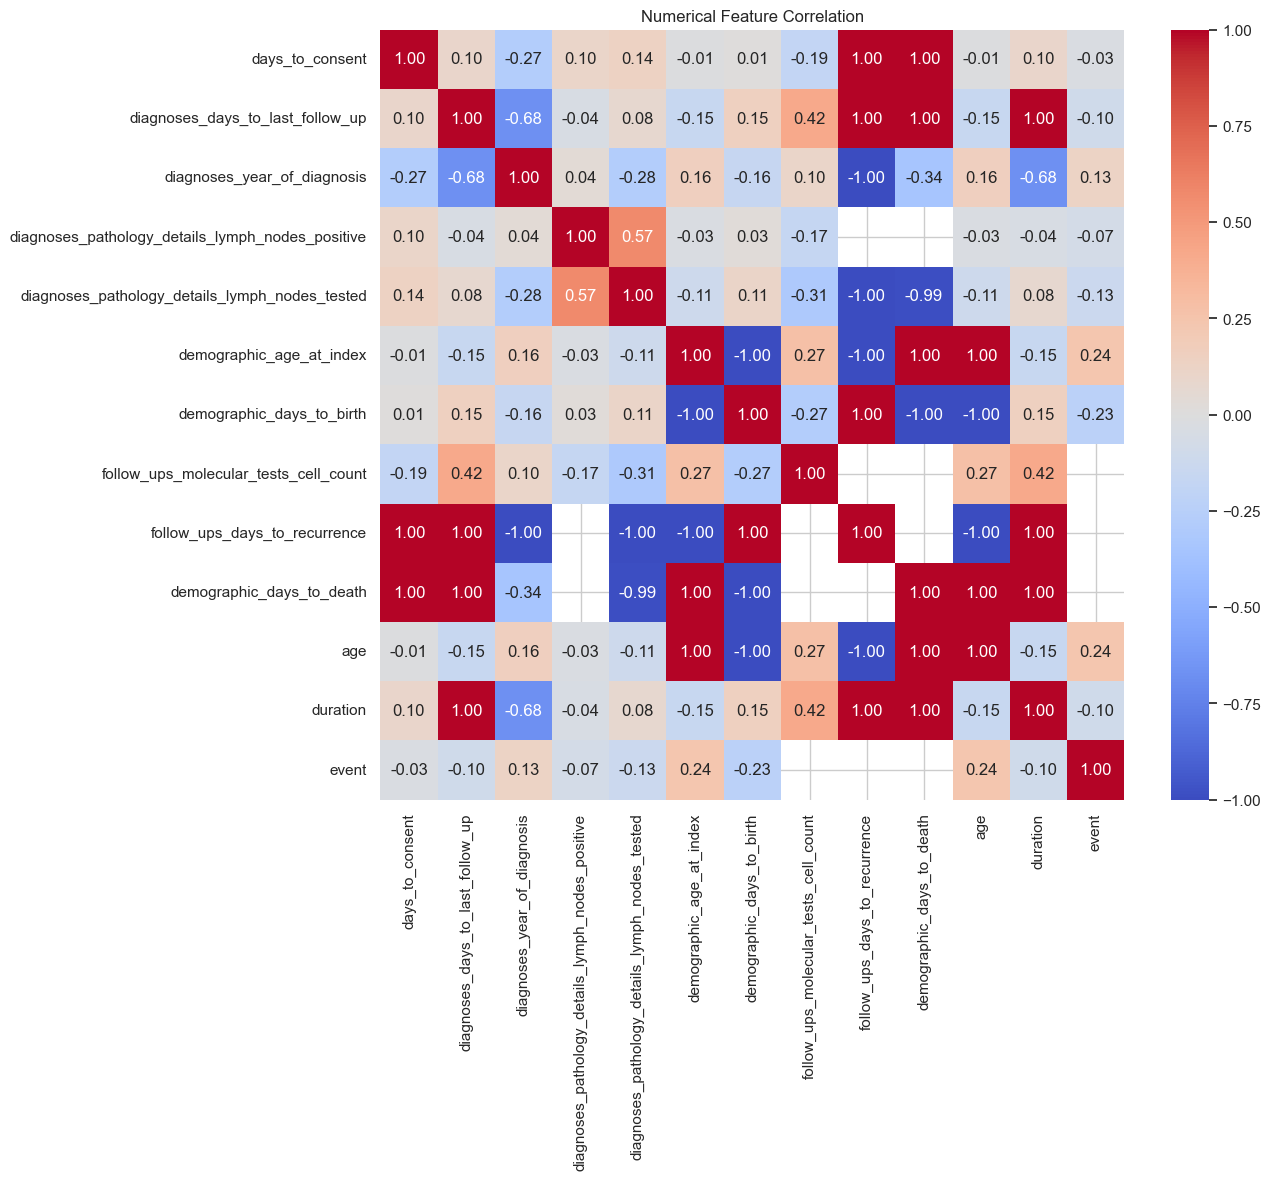

In [33]:
plt.figure(figsize=(12, 10))
numeric_cols = Clinical_Demographic.select_dtypes(include=[np.number]).columns
# Filter out columns with all NaNs
numeric_cols = [c for c in numeric_cols if Clinical_Demographic[c].nunique() > 1]
sns.heatmap(Clinical_Demographic[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Numerical Feature Correlation')
plt.show()

Specialized Insights

In [ ]:
print("\n### 3. Clinical Insights ###")
# Average age by Menopause Status
if 'follow_ups_other_clinical_attributes_menopause_status' in Clinical_Demographic.columns:
    menopause_age = Clinical_Demographic.groupby('follow_ups_other_clinical_attributes_menopause_status')['demographic_age_at_index'].mean()
    print("\nAverage Age by Menopause Status:")
    print(menopause_age)



### 3. Clinical Insights ###

Average Age by Menopause Status:
follow_ups_other_clinical_attributes_menopause_status
Perimenopausal    49.666667
Postmenopausal    61.262295
Premenopausal     42.791667
Unknown           49.666667
Name: demographic_age_at_index, dtype: float64


Helper functions

In [ ]:
def get_first_val(x):
    if pd.isna(x): return np.nan
    return str(x).split('|')[0].strip()

def extract_marker_status(row, marker_name):
    try:
        genes = str(row['follow_ups_molecular_tests_gene_symbol']).split('|')
        results = str(row['follow_ups_molecular_tests_test_result']).split('|')
        gene_map = dict(zip([g.strip() for g in genes], [r.strip() for r in results]))
        return gene_map.get(marker_name, "Unknown")
    except:
        return "Unknown"

Data Cleaning and Feature Engineering

In [18]:
# 1. Basic Cleaning
Clinical_Demographic['clean_stage'] = Clinical_Demographic['diagnoses_ajcc_pathologic_stage'].str.extract(r'(Stage [IV]+)')
Clinical_Demographic['age'] = Clinical_Demographic['demographic_age_at_index']

# 2. Molecular Subtyping
Clinical_Demographic['ER_Status'] = Clinical_Demographic.apply(lambda x: extract_marker_status(x, 'ESR1'), axis=1)
Clinical_Demographic['PR_Status'] = Clinical_Demographic.apply(lambda x: extract_marker_status(x, 'PGR'), axis=1)
Clinical_Demographic['HER2_Status'] = Clinical_Demographic.apply(lambda x: extract_marker_status(x, 'ERBB2'), axis=1)

# 3. Survival Prep
# TCGA: If death days is NaN, use last follow up
Clinical_Demographic['duration'] = Clinical_Demographic['demographic_days_to_death'].fillna(Clinical_Demographic['diagnoses_days_to_last_follow_up'])
Clinical_Demographic['event'] = Clinical_Demographic['demographic_vital_status'].map({'Dead': 1, 'Alive': 0})

Age Distribution by Stage

C:\Users\USER\AppData\Local\Temp\ipykernel_20848\3942438498.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=Clinical_Demographic, x='clean_stage', y='age', palette='vlag')


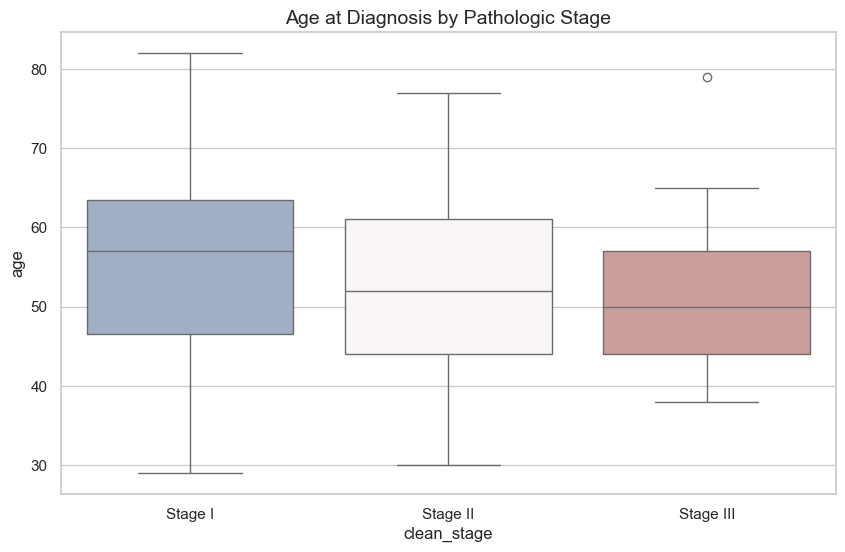

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=Clinical_Demographic, x='clean_stage', y='age', palette='vlag')
plt.title('Age at Diagnosis by Pathologic Stage', fontsize=14)
plt.show()

Molecular Marker Distribution

<Figure size 1000x600 with 0 Axes>

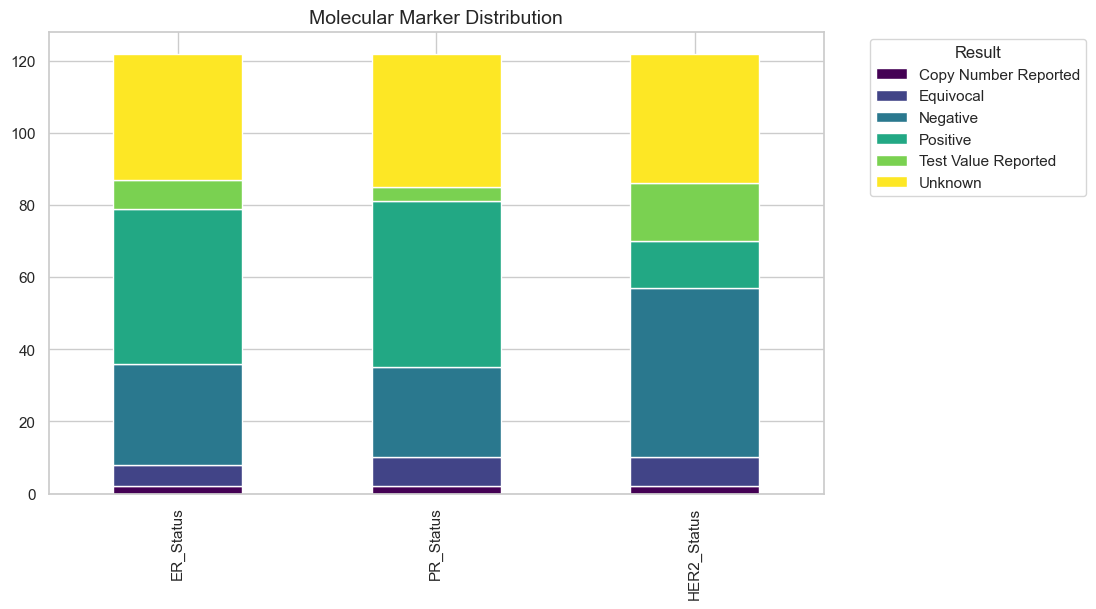

In [21]:
plt.figure(figsize=(10, 6))
marker_counts = Clinical_Demographic[['ER_Status', 'PR_Status', 'HER2_Status']].apply(pd.Series.value_counts).T
marker_counts.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 6))
plt.title('Molecular Marker Distribution', fontsize=14)
plt.legend(title="Result", bbox_to_anchor=(1.05, 1), loc='upper left')

Treatment Modalities

C:\Users\USER\AppData\Local\Temp\ipykernel_20848\52300960.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=treatments, palette='rocket')


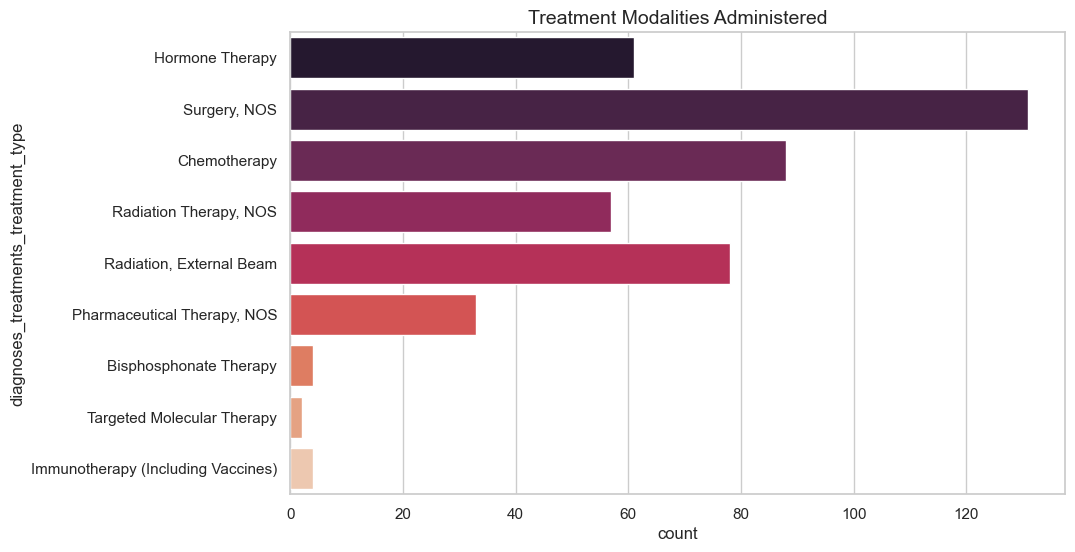

In [23]:
plt.figure(figsize=(10, 6))
treatments = Clinical_Demographic['diagnoses_treatments_treatment_type'].str.split('|').explode().str.strip()
sns.countplot(y=treatments, palette='rocket')
plt.title('Treatment Modalities Administered', fontsize=14)
plt.show()

Survival Analysis (Kaplan-Meier)

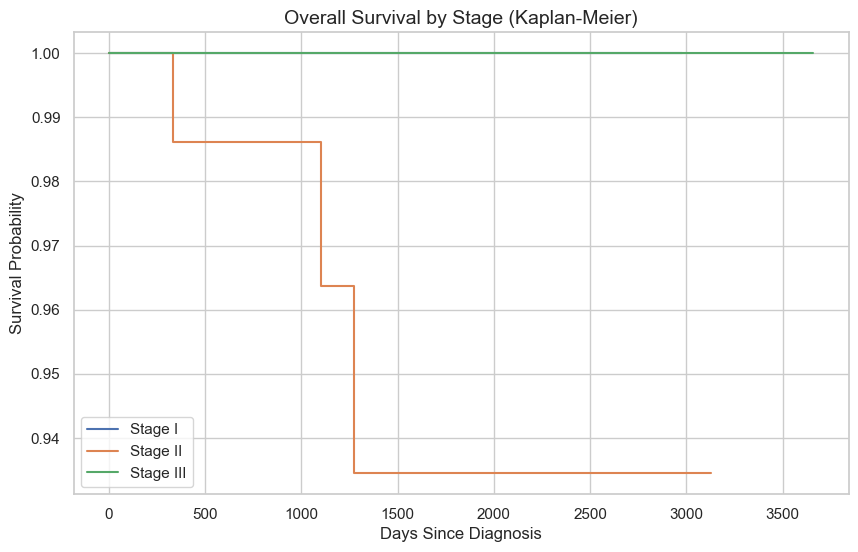

In [24]:
plt.figure(figsize=(10, 6))
kmf = KaplanMeierFitter()

# Iterate through stages to plot multiple curves
for stage in Clinical_Demographic['clean_stage'].dropna().unique():
    mask = (Clinical_Demographic['clean_stage'] == stage)
    # Ensure there is data to plot for the stage
    if mask.any():
        kmf.fit(Clinical_Demographic[mask]['duration'], 
                Clinical_Demographic[mask]['event'], 
                label=stage)
        kmf.plot_survival_function(ci_show=False)

plt.title('Overall Survival by Stage (Kaplan-Meier)', fontsize=14)
plt.xlabel('Days Since Diagnosis')
plt.ylabel('Survival Probability')
plt.show()

Statistical Summary

In [25]:
print("--- CLINICAL COHORT SUMMARY ---")
summary = Clinical_Demographic[['age', 'clean_stage', 'demographic_vital_status']].describe(include='all')
display(summary)

--- CLINICAL COHORT SUMMARY ---


,age,clean_stage,demographic_vital_status
count,122.000000,121,122
unique,NaN,3,2
top,NaN,Stage II,Alive
freq,NaN,75,119
mean,52.901639,NaN,NaN
std,11.341003,NaN,NaN
min,29.000000,NaN,NaN
25%,44.250000,NaN,NaN
50%,52.000000,NaN,NaN
75%,61.000000,NaN,NaN


------

Data Loading and Preprocessing

In [27]:
# 1. Load the Data
# Note: Ensure the file path is accessible from your notebook environment
Clinical_Treatment = pd.read_csv('D:\\TCGA-BRCA\\Uploading\\Clinical_Treatment_Data.csv')

# --- DATA PREPARATION ---
# Clean vital status robustly
Clinical_Treatment['vital_status_clean'] = Clinical_Treatment['vital_status'].astype(str).str.strip().str.lower()
Clinical_Treatment['event_observed'] = Clinical_Treatment['vital_status_clean'].apply(lambda x: 1 if x in ['dead', 'deceased'] else 0)

# Clean Drug Columns (creating grouped binary columns)
drug_mappings = {
    'Fluorouracil': [c for c in Clinical_Treatment.columns if 'fluoro' in c.lower() or '5-fu' in c.lower()],
    'Cyclophosphamide': [c for c in Clinical_Treatment.columns if 'cyclo' in c.lower() or 'cytoxan' in c.lower()],
    'Doxorubicin': [c for c in Clinical_Treatment.columns if 'doxorubicin' in c.lower() or 'adriamycin' in c.lower()],
    'Paclitaxel': [c for c in Clinical_Treatment.columns if 'paclitaxel' in c.lower() or 'taxol' in c.lower()],
    'Trastuzumab': [c for c in Clinical_Treatment.columns if 'trastuzumab' in c.lower() or 'herceptin' in c.lower()],
    'Hormone_Therapy': [c for c in Clinical_Treatment.columns if 'tamoxifen' in c.lower() or 'letrozole' in c.lower() or 'anastrozole' in c.lower()]
}

for new_col, old_cols in drug_mappings.items():
    Clinical_Treatment[new_col] = Clinical_Treatment[old_cols].sum(axis=1).apply(lambda x: 1 if x > 0 else 0)

# Define Clinical Subtypes
def determine_subtype(row):
    er, pr, her2 = str(row['er_status_by_ihc']).lower(), str(row['pr_status_by_ihc']).lower(), str(row['her2_status_by_ihc']).lower()
    if 'positive' in er or 'positive' in pr:
        return 'HR+/HER2-' if her2 != 'positive' else 'HR+/HER2+' 
    elif her2 == 'positive':
        return 'HER2+ (HR-)'
    elif er == 'negative' and pr == 'negative' and her2 == 'negative':
        return 'TNBC'
    return 'Unknown'

Clinical_Treatment['Subtype'] = Clinical_Treatment.apply(determine_subtype, axis=1)
print("Data Preprocessing Complete.")

Data Preprocessing Complete.


Age at Diagnosis by Subtype

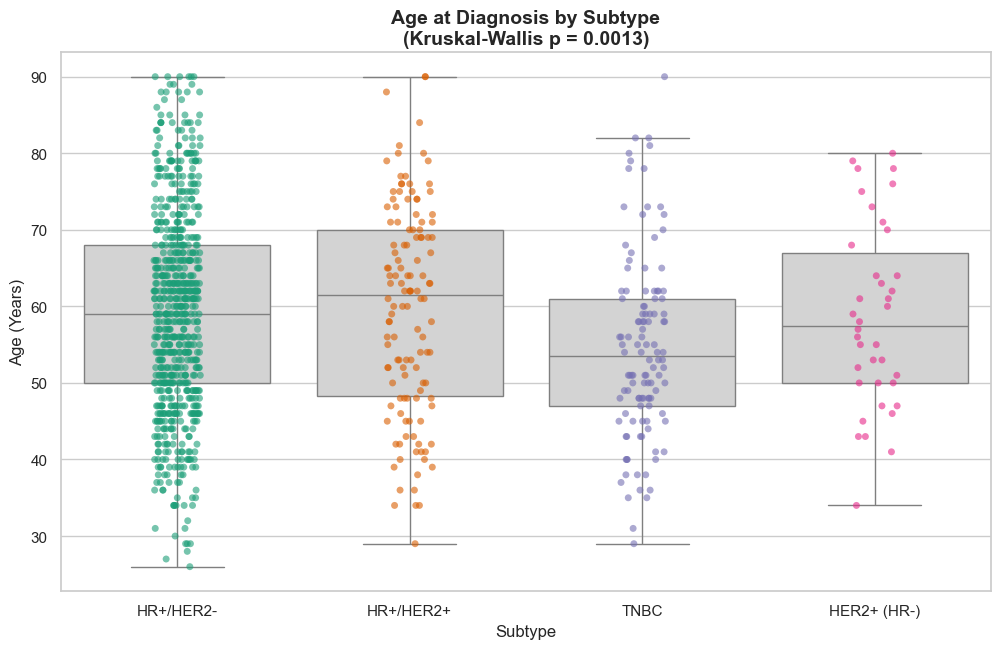

In [28]:
plt.figure(figsize=(12, 7))

# Filter data for visualization
valid_age_df = Clinical_Treatment.dropna(subset=['age_at_diagnosis', 'Subtype'])
valid_age_df = valid_age_df[valid_age_df['Subtype'] != 'Unknown']

# Create plot
sns.boxplot(data=valid_age_df, x='Subtype', y='age_at_diagnosis', color="lightgray", showfliers=False)
sns.stripplot(data=valid_age_df, x='Subtype', y='age_at_diagnosis', alpha=0.6, jitter=True, palette="Dark2", hue='Subtype', legend=False)

# Statistical Test
groups = [group["age_at_diagnosis"].values for name, group in valid_age_df.groupby("Subtype")]
if len(groups) > 1:
    stat, p_val = kruskal(*groups)
    plt.title(f'Age at Diagnosis by Subtype\n(Kruskal-Wallis p = {p_val:.4f})', fontweight='bold', fontsize=14)
else:
    plt.title('Age at Diagnosis by Subtype', fontweight='bold', fontsize=14)

plt.ylabel('Age (Years)')
plt.show()

Treatment Co-occurrence Heatmap

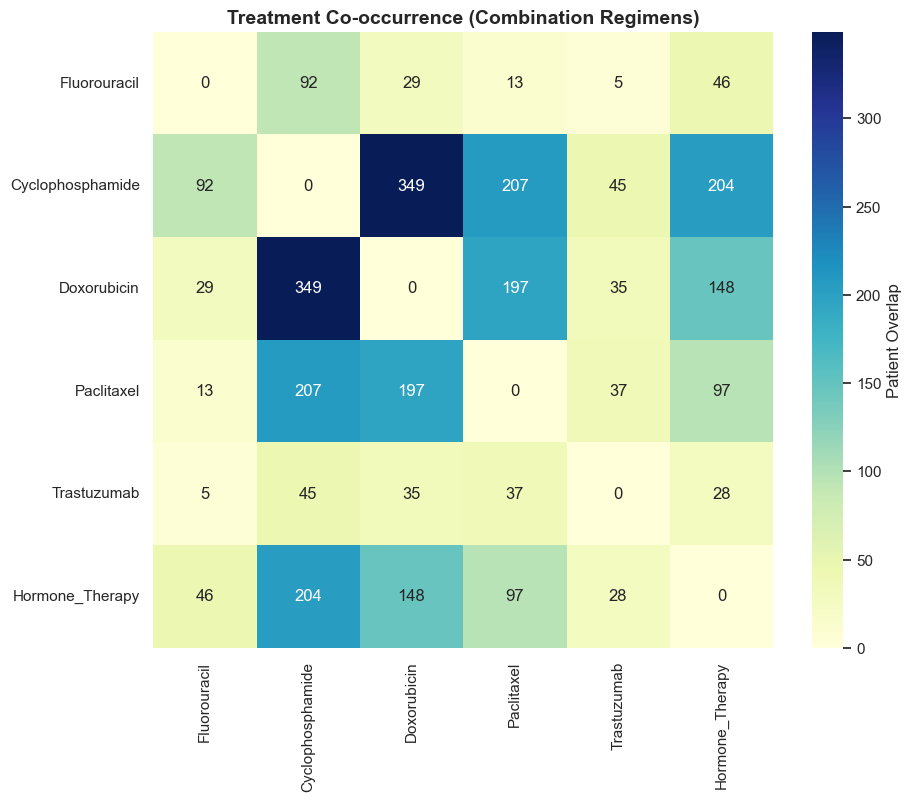

In [29]:
plt.figure(figsize=(10, 8))

drug_cols = list(drug_mappings.keys())
co_occurrence = Clinical_Treatment[drug_cols].T.dot(Clinical_Treatment[drug_cols])
np.fill_diagonal(co_occurrence.values, 0) # Highlight relationships by removing self-overlap

sns.heatmap(co_occurrence, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': 'Patient Overlap'})
plt.title('Treatment Co-occurrence (Combination Regimens)', fontweight='bold', fontsize=14)
plt.show()

Kaplan-Meier Survival Analysis

Total events (deaths) captured: 0


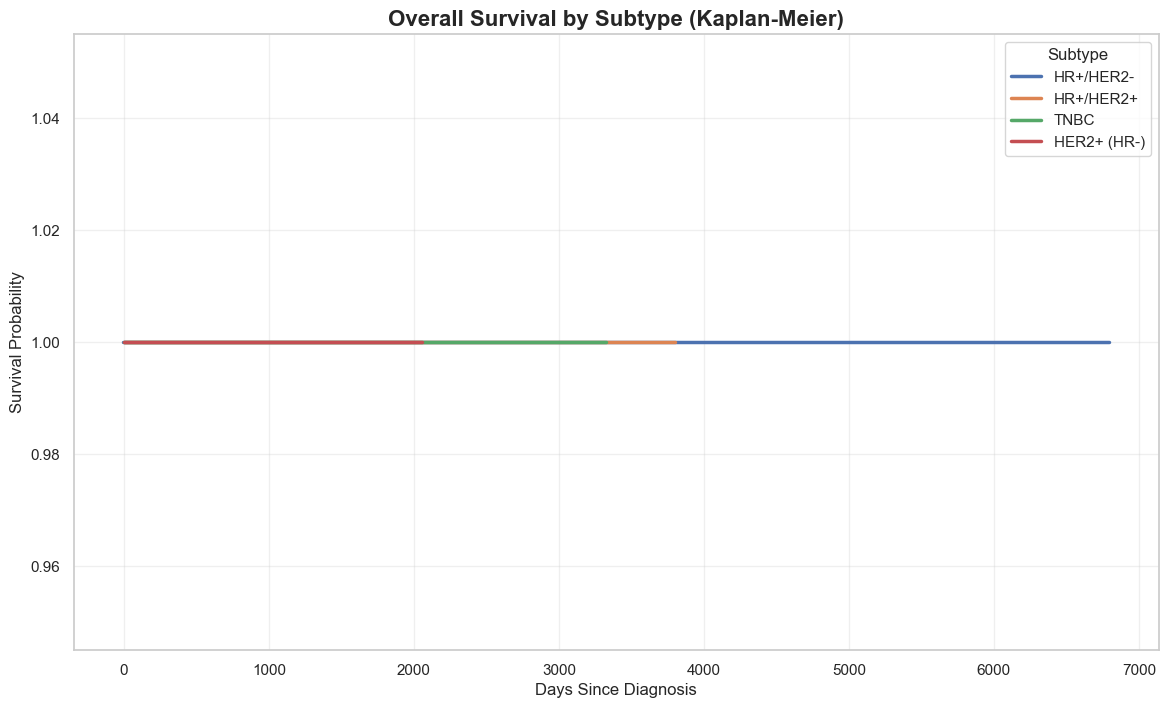

In [30]:
plt.figure(figsize=(14, 8))
kmf = KaplanMeierFitter()

# Clean records missing survival time
surv_df = Clinical_Treatment.dropna(subset=['last_contact_days_to']).copy()

print(f"Total events (deaths) captured: {surv_df['event_observed'].sum()}") 

for subtype in surv_df['Subtype'].unique():
    if subtype == 'Unknown': 
        continue
        
    mask = surv_df['Subtype'] == subtype
    # Filter for subtypes with enough data points to be statistically relevant
    if mask.sum() > 5: 
        kmf.fit(surv_df['last_contact_days_to'][mask], 
                surv_df['event_observed'][mask], 
                label=subtype)
        
        # ci_show=True adds shaded confidence intervals
        kmf.plot_survival_function(ci_show=True, linewidth=2.5)

plt.title('Overall Survival by Subtype (Kaplan-Meier)', fontweight='bold', fontsize=16)
plt.xlabel('Days Since Diagnosis')
plt.ylabel('Survival Probability')
plt.legend(title="Subtype")
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
print("--- COHORT BREAKDOWN ---")
print(Clinical_Treatment['Subtype'].value_counts())
print("\n--- TREATMENT FREQUENCIES ---")
print(Clinical_Treatment[list(drug_mappings.keys())].sum())

--- COHORT BREAKDOWN ---
Subtype
HR+/HER2-      699
HR+/HER2+      126
Unknown        118
TNBC           116
HER2+ (HR-)     38
Name: count, dtype: int64

--- TREATMENT FREQUENCIES ---
Fluorouracil         92
Cyclophosphamide    507
Doxorubicin         357
Paclitaxel          226
Trastuzumab          73
Hormone_Therapy     340
dtype: int64


DATA QUALITY AUDIT

<Figure size 800x400 with 0 Axes>

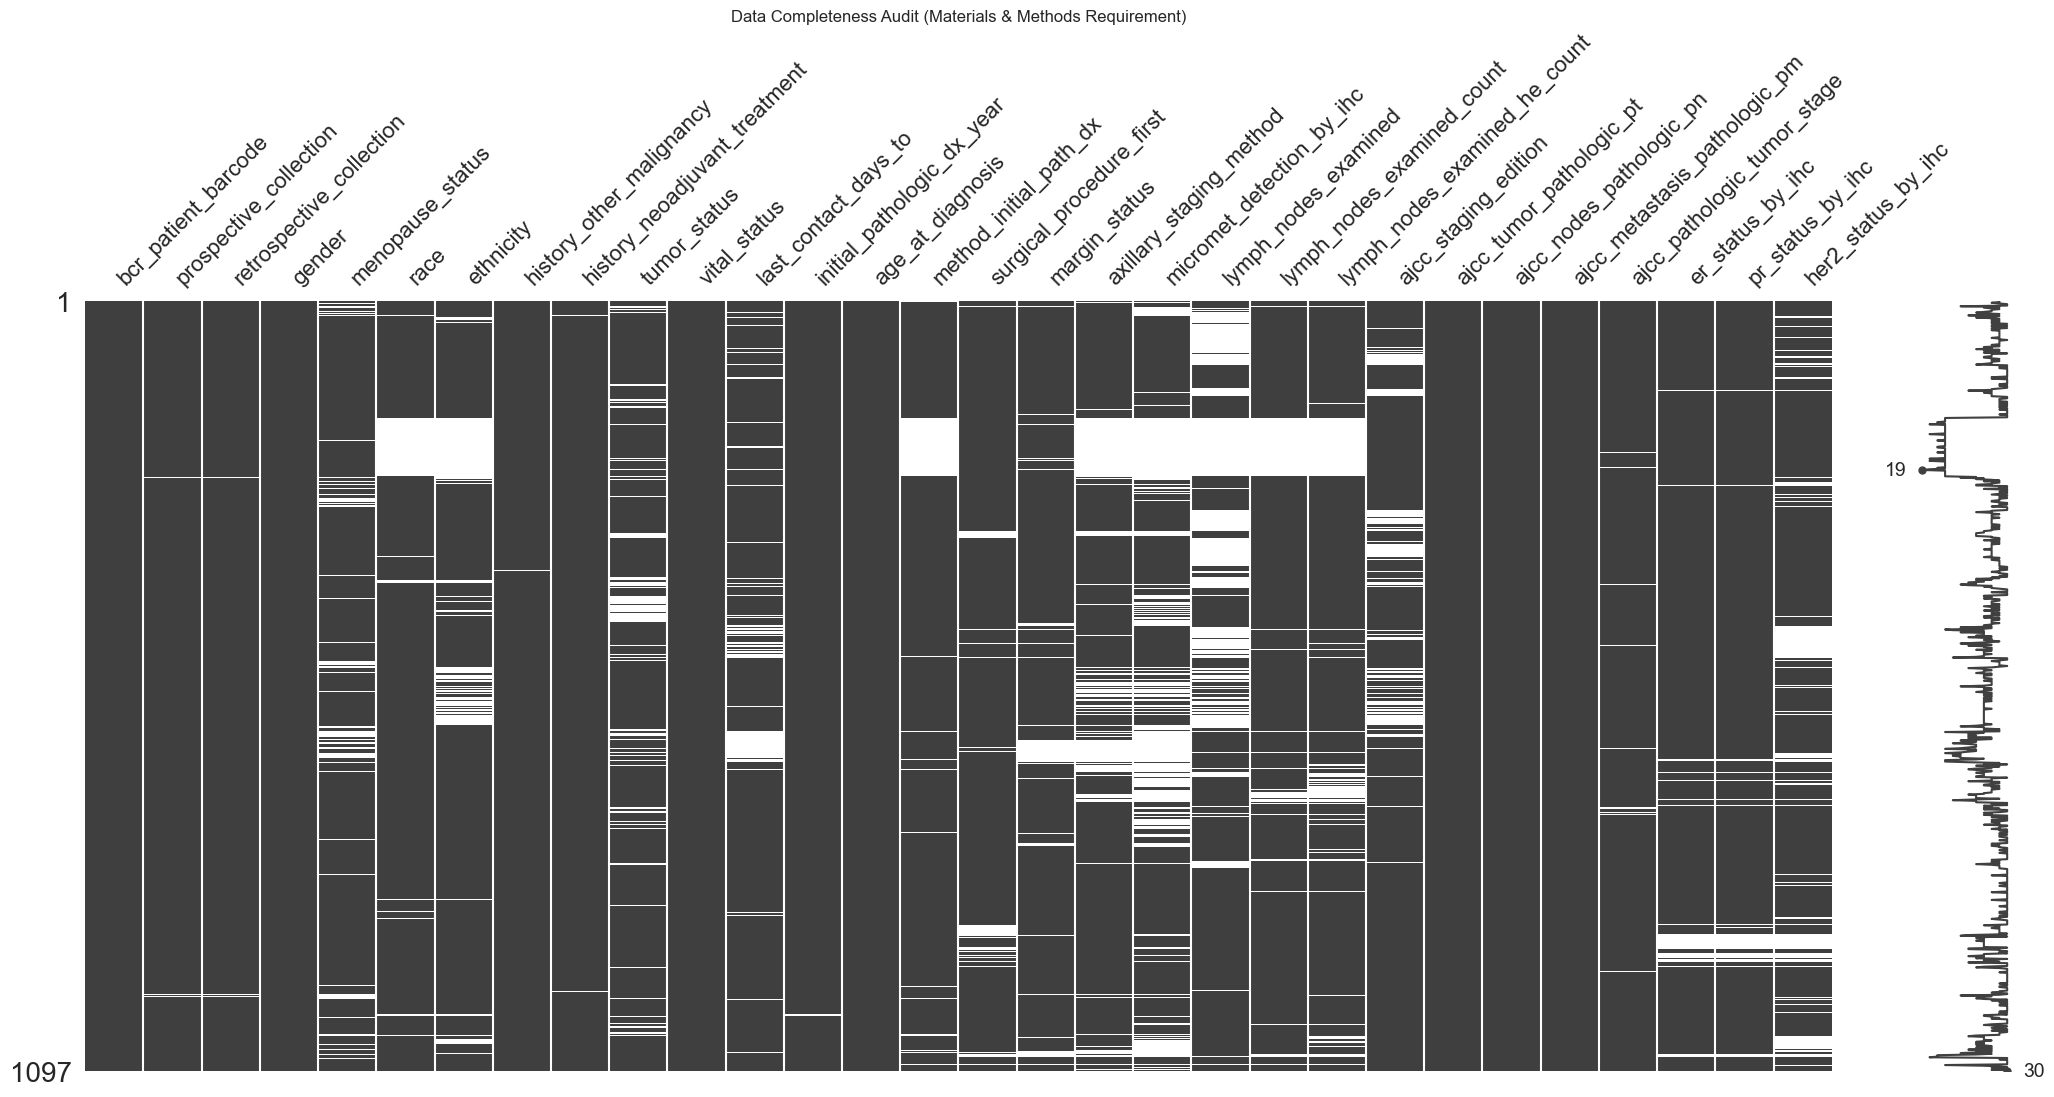

In [36]:
plt.figure(figsize=(8, 4))
msno.matrix(Clinical_Treatment.iloc[:, :30]) # Audit first 30 columns for missingness
plt.title("Data Completeness Audit (Materials & Methods Requirement)")
plt.show()


ADVANCED PATHOLOGICAL ANALYSIS

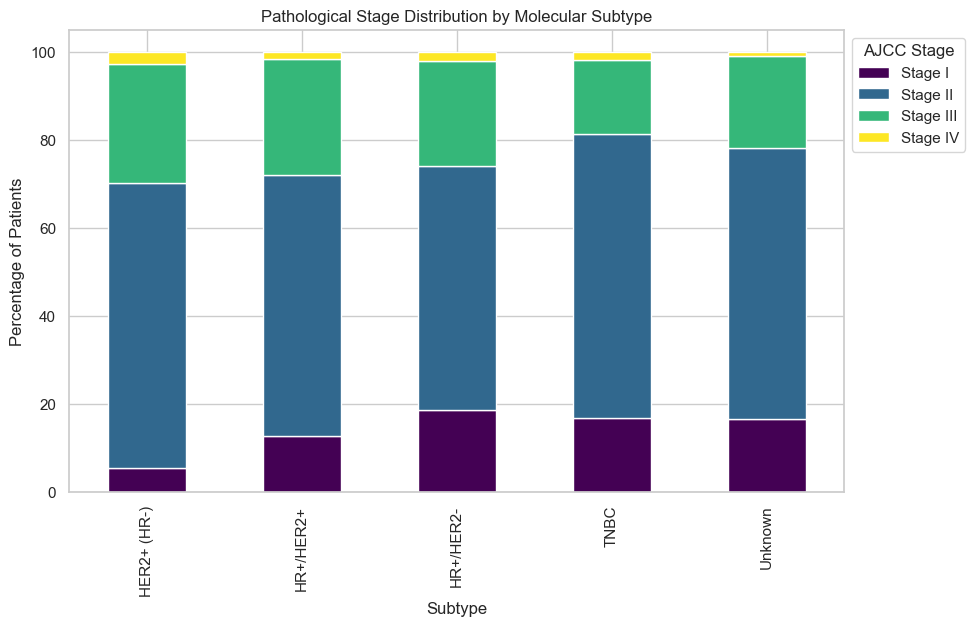

In [37]:
# Simplify Stage for better visualization
Clinical_Treatment['stage_simple'] = Clinical_Treatment['ajcc_pathologic_tumor_stage'].str.extract(r'(Stage [I|V]+)')

# Cross-tabulation of Subtype vs Stage
ct = pd.crosstab(Clinical_Treatment['Subtype'], Clinical_Treatment['stage_simple'], normalize='index') * 100

ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title("Pathological Stage Distribution by Molecular Subtype")
plt.ylabel("Percentage of Patients")
plt.legend(title="AJCC Stage", bbox_to_anchor=(1,1))
plt.show()

THE DOCTORAL STEP: COX PROPORTIONAL HAZARDS

<Figure size 1000x600 with 0 Axes>

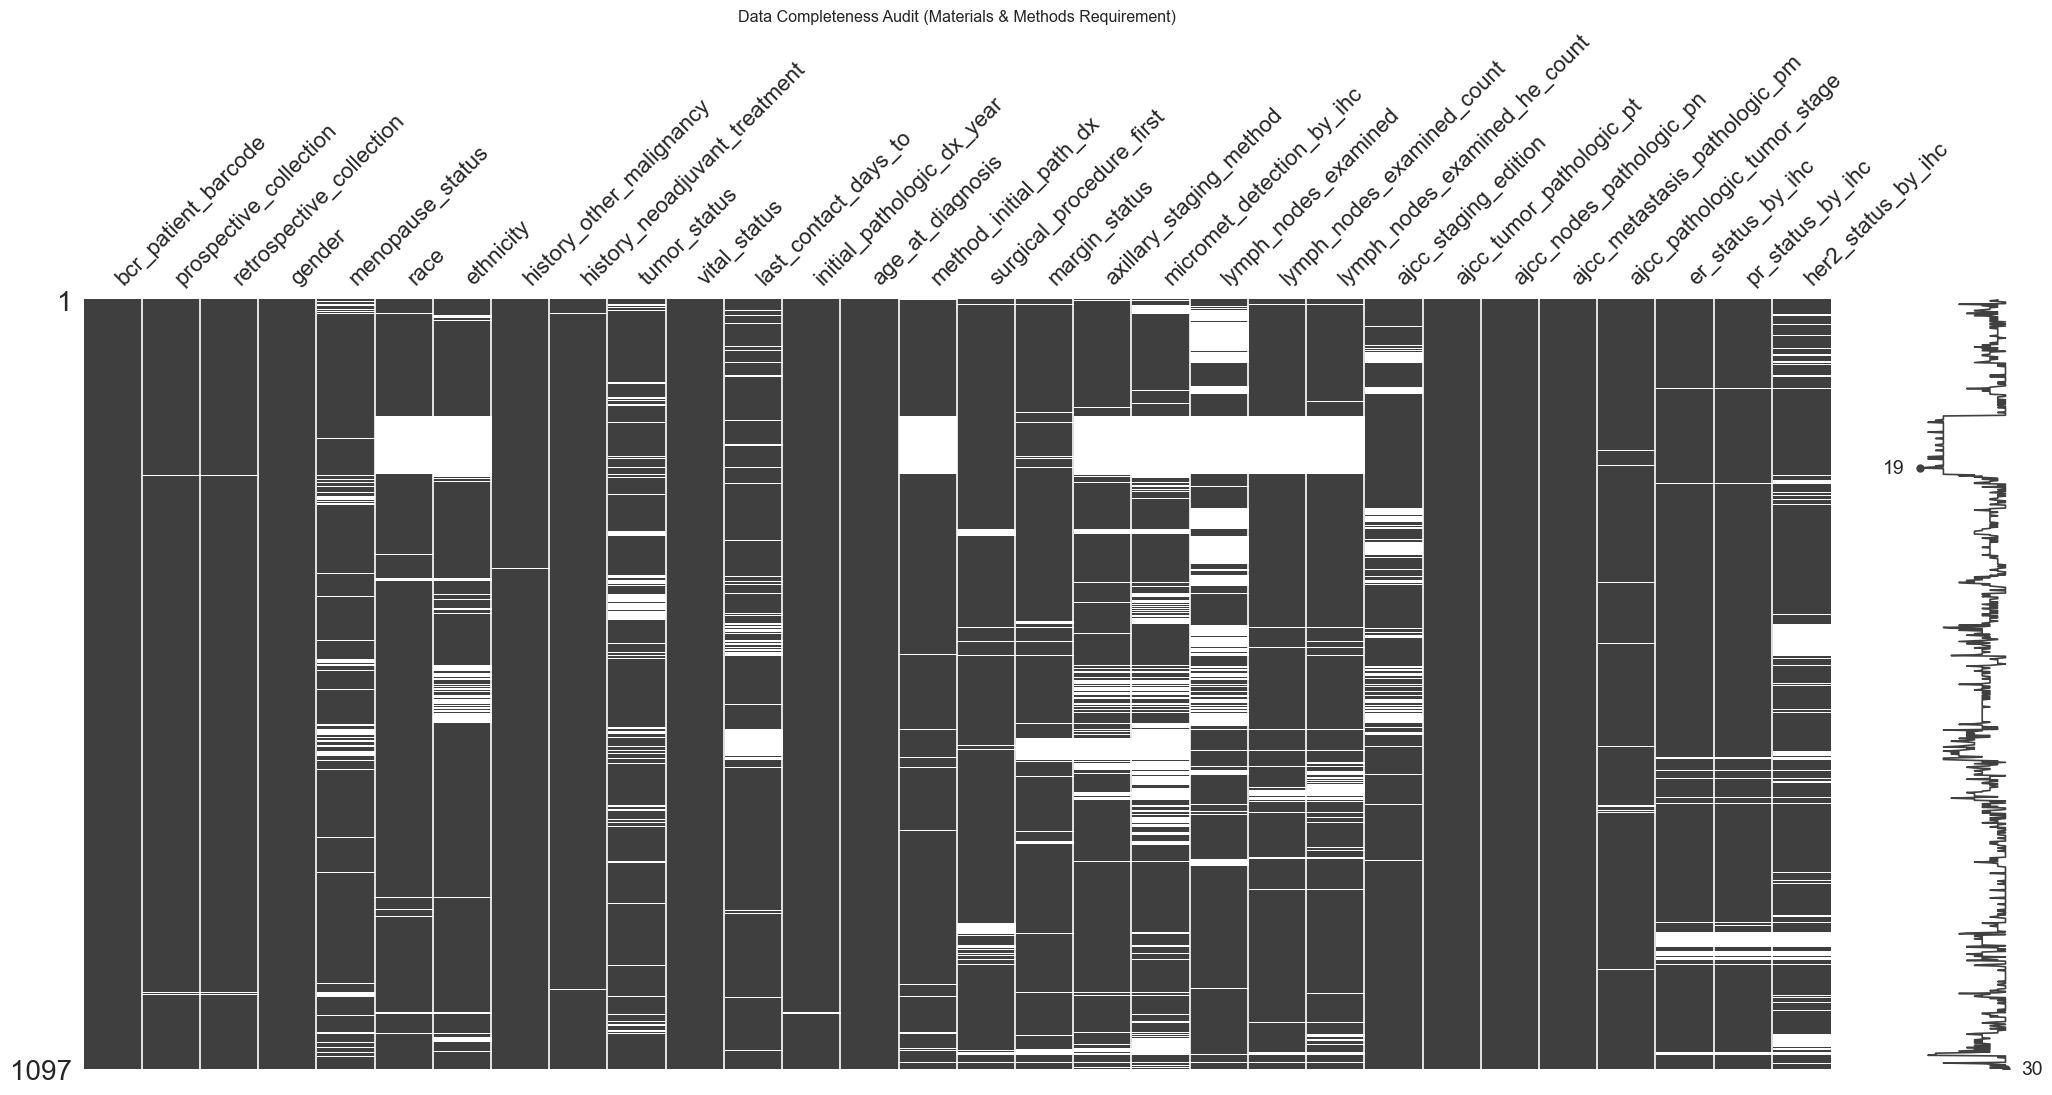

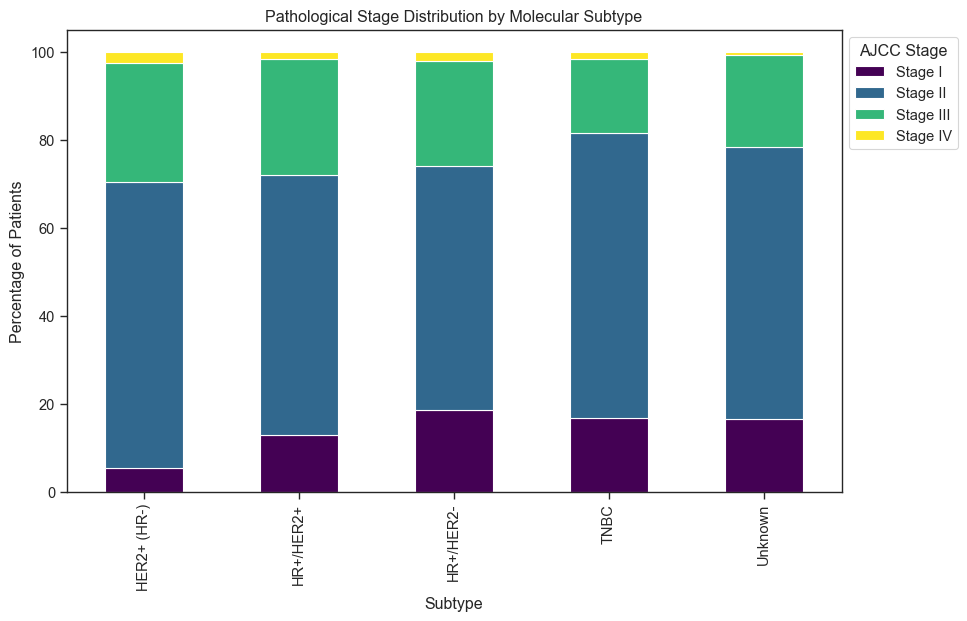


--- COX PROPORTIONAL HAZARDS MODEL ---
Model failed: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.. (Likely due to low event count in this specific CSV slice)


In [ ]:


# 2. 
def analyze_pathology(Clinical_Treatment):
    

# 3. 
def run_cox_model(Clinical_Treatment):
    print("\n--- COX PROPORTIONAL HAZARDS MODEL ---")
    # Preparing data for Cox: Must be numeric and no NaNs
    cox_data = Clinical_Treatment[['last_contact_days_to', 'event_observed', 'age_at_diagnosis', 'Subtype', 'stage_simple']].dropna()
    
    # Convert categorical to dummies
    cox_data = pd.get_dummies(cox_data, columns=['Subtype', 'stage_simple'], drop_first=True)
    
    cph = CoxPHFitter()
    try:
        cph.fit(cox_data, duration_col='last_contact_days_to', event_col='event_observed')
        cph.print_summary()  # This gives you Hazard Ratios and P-values
        
        # Plotting the Forest Plot (Essential for papers!)
        plt.figure(figsize=(10, 6))
        cph.plot()
        plt.title("Hazard Ratios for Clinical Features (Cox Model)")
        plt.show()
    except Exception as e:
        print(f"Model failed: {e}. (Likely due to low event count in this specific CSV slice)")

# Execute
audit_data_quality(Clinical_Treatment)
analyze_pathology(Clinical_Treatment)
run_cox_model(Clinical_Treatment)

C:\Users\USER\AppData\Local\Temp\ipykernel_19924\222290629.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Subtype', y='LNR', inner="quart", palette="muted")


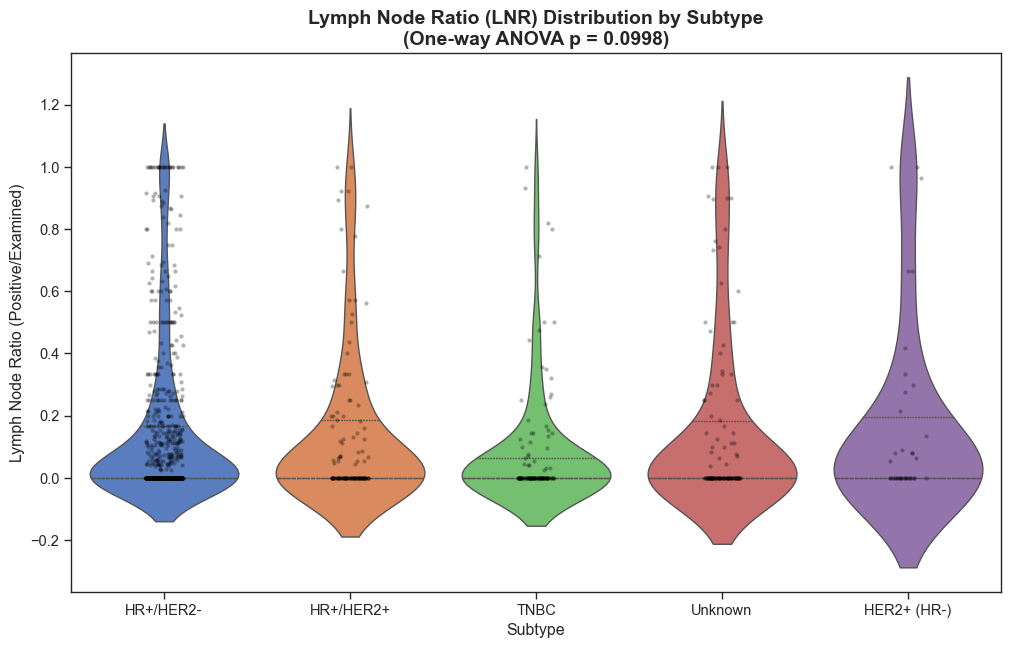

--- TABLE 1: CLINICAL CHARACTERISTICS BY MOLECULAR SUBTYPE ---
             age_at_diagnosis  lymph_nodes_examined_count    LNR    N
Subtype                                                              
HER2+ (HR-)              57.5                      12.633  0.169   38
HR+/HER2+                61.5                      11.051  0.141  126
HR+/HER2-                59.0                      10.600  0.149  699
TNBC                     53.5                      10.110  0.088  116
Unknown                  56.0                      10.540  0.153  118


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

# 1. Calculate Lymph Node Ratio (LNR) - A high-impact clinical metric
# LNR = (Positive Nodes / Total Nodes Examined)
# We handle division by zero or NaN
df['LNR'] = df['lymph_nodes_examined_he_count'] / df['lymph_nodes_examined_count']
df['LNR'] = df['LNR'].replace([np.inf, -np.inf], np.nan).fillna(0)

# 2. Advanced Visualization: LNR by Subtype
plt.figure(figsize=(12, 7))
sns.violinplot(data=df, x='Subtype', y='LNR', inner="quart", palette="muted")
sns.stripplot(data=df, x='Subtype', y='LNR', color="black", size=3, alpha=0.3)

# 3. Statistical Validation (ANOVA)
subtypes = df['Subtype'].unique()
group_data = [df[df['Subtype'] == s]['LNR'].dropna() for s in subtypes if s != 'Unknown']
f_stat, p_val = f_oneway(*group_data)

plt.title(f"Lymph Node Ratio (LNR) Distribution by Subtype\n(One-way ANOVA p = {p_val:.4f})", 
          fontsize=14, fontweight='bold')
plt.ylabel("Lymph Node Ratio (Positive/Examined)")
plt.show()

# 4. Professional Summary Table for your Thesis
clinical_summary = df.groupby('Subtype').agg({
    'age_at_diagnosis': 'median',
    'lymph_nodes_examined_count': 'mean',
    'LNR': 'mean',
    'bcr_patient_barcode': 'count'
}).rename(columns={'bcr_patient_barcode': 'N'})

print("--- TABLE 1: CLINICAL CHARACTERISTICS BY MOLECULAR SUBTYPE ---")
print(clinical_summary.round(3))